<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20ECO003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

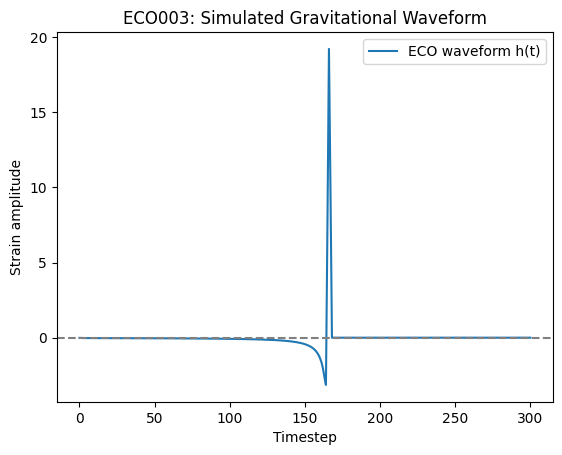

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
M = 10.0
alpha = 0.25  # collapse regime
beta = 0.02
gamma = 0.2
R_c = 1.5
timesteps = 300
G = 1.0
c = 1.0

def S(R): return gamma * np.log(1 + R/R_c)
def collapse_step(R): return R - alpha * M / (R**2) + beta * S(R)

# Simulate collapse
R_vals = [10.0]
for t in range(timesteps):
    R_next = max(collapse_step(R_vals[-1]), R_c)
    R_vals.append(R_next)

# Compute quadrupole moment Q(t) = M * R(t)^2
Q_vals = M * np.array(R_vals)**2

# Approximate second derivative of Q(t)
d2Q_dt2 = np.gradient(np.gradient(Q_vals))

# Compute strain h(t)
h_vals = (2 * G / c**4) * d2Q_dt2

# Plot
plt.plot(h_vals, label="ECO waveform h(t)")
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Timestep")
plt.ylabel("Strain amplitude")
plt.title("ECO003: Simulated Gravitational Waveform")
plt.legend()
plt.show()
